# Gradient Descent

In [10]:
# 1. Define the function we want to minimize: f(x) = x^2
def function_to_minimize(x):
    return x**2

# 2. Define the Gradient (the derivative): f'(x) = 2x
# The gradient tells us the "slope" at any point x.
def get_gradient(x):
    return 2 * x

# 3. Gradient Descent Parameters
current_x = 100        # Start at a random spot (e.g., x = 10)
learning_rate = 0.1    # Size of each step
iterations = 50     # How many steps to take

print(f"Starting at x = {current_x}")

# 4. The Training Loop
for i in range(iterations):
    # Calculate the slope at our current position
    slope = get_gradient(current_x)
    
    # Update current_x by moving in the OPPOSITE direction of the slope
    # x_new = x_old - (learning_rate * slope)
    current_x = current_x - (learning_rate * slope)
    
    # Print progress every 5 steps
    if i % 5 == 0:
        print(f"Iteration {i}: x = {current_x:.4f}, f(x) = {function_to_minimize(current_x):.4f}")

print(f"\nFinal result: The minimum is approximately at x = {current_x:.4f}")

Starting at x = 100
Iteration 0: x = 80.0000, f(x) = 6400.0000
Iteration 5: x = 26.2144, f(x) = 687.1948
Iteration 10: x = 8.5899, f(x) = 73.7870
Iteration 15: x = 2.8147, f(x) = 7.9228
Iteration 20: x = 0.9223, f(x) = 0.8507
Iteration 25: x = 0.3022, f(x) = 0.0913
Iteration 30: x = 0.0990, f(x) = 0.0098
Iteration 35: x = 0.0325, f(x) = 0.0011
Iteration 40: x = 0.0106, f(x) = 0.0001
Iteration 45: x = 0.0035, f(x) = 0.0000

Final result: The minimum is approximately at x = 0.0014


In [13]:
!pip install numpy matplotlib

# Gradient Descent Formula for a Linear Model

## 1. Linear Model (Hypothesis)

For linear regression with one feature:

$$
\hat{y} = h_\theta(x) = w x + b
$$

Where:
- `w` = weight  
- `b` = bias  
- `x` = input feature  
- `\hat{y}` = predicted value  

---

## 2. Cost Function (Mean Squared Error)

For `m` training examples:

$$
J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2
$$

The factor `1/2` simplifies gradient calculations.

---

## 3. Gradients

### Gradient with respect to weight `w`

$$
\frac{\partial J}{\partial w}
= \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \, x^{(i)}
$$

---

### Gradient with respect to bias `b`

$$
\frac{\partial J}{\partial b}
= \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})
$$

---

## 4. Gradient Descent Update Rules

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Where:
- `\alpha` = learning rate  

---

## 5. Vectorized Form (Multiple Features)

### Model

$$
\hat{y} = Xw + b
$$

### Gradient with respect to `w`

$$
\nabla_w J = \frac{1}{m} X^T (Xw + b - y)
$$

### Gradient with respect to `b`

$$
\frac{\partial J}{\partial b}
= \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(_


Iteration 0: m=0.04, b=0.01, Loss=45.1360
Iteration 100: m=1.72, b=0.46, Loss=0.4265
Iteration 200: m=1.88, b=0.48, Loss=0.0518
Iteration 300: m=1.89, b=0.47, Loss=0.0461
Iteration 400: m=1.90, b=0.46, Loss=0.0437
Iteration 500: m=1.90, b=0.44, Loss=0.0414
Iteration 600: m=1.91, b=0.43, Loss=0.0393
Iteration 700: m=1.91, b=0.42, Loss=0.0373
Iteration 800: m=1.91, b=0.40, Loss=0.0354
Iteration 900: m=1.92, b=0.39, Loss=0.0337

Training Complete!
Final Equation: y = 1.92x + 0.38


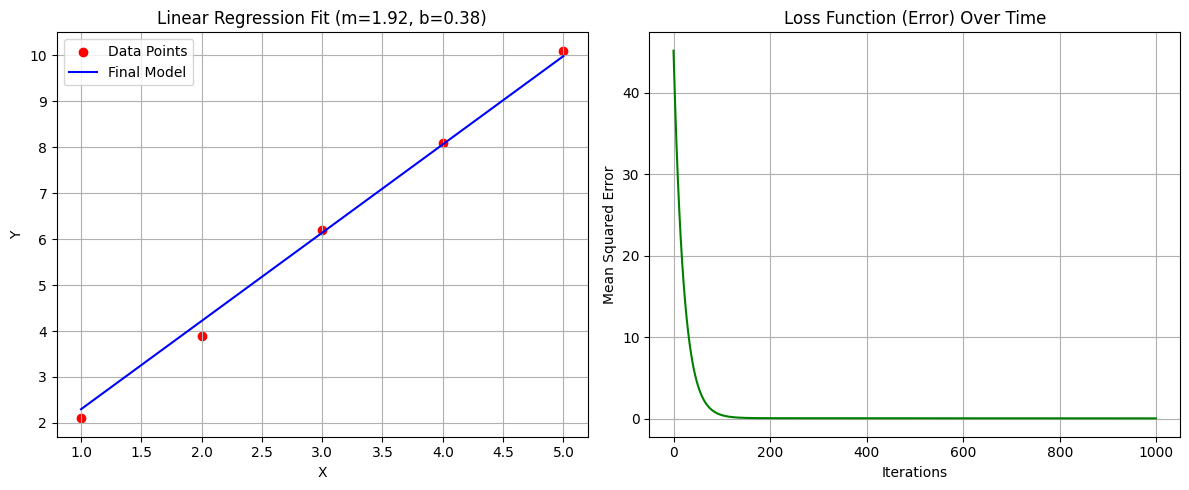

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP DATA ---
# X = Input (Independent Variable)
# Y = Target (Dependent Variable)
X = np.array([1, 2, 3, 4, 5])
Y = np.array([2.1, 3.9, 6.2, 8.1, 10.1])

# --- 2. HYPERPARAMETERS ---
learning_rate = 0.001  # Alpha (Size of the step)
iterations = 1000     # How many times to "learn"
n = len(X)            # Number of data points

# --- 3. INITIALIZATION ---
m = 0.0  # Slope (Weight) - Start at 0
b = 0.0  # Intercept (Bias) - Start at 0

# Lists to store error history for visualization (optional)
loss_history = []

# --- 4. THE TRAINING LOOP ---
for i in range(iterations):
    
    # === A. LINEAR MODEL (The Prediction) ===
    # Formula: y_pred = mx + b
    Y_pred = m * X + b
    
    # === B. LOSS FUNCTION (The Cost) ===
    # Formula: MSE = (1/n) * sum((y - y_pred)^2)
    # We calculate this just to track progress, not for the math updates
    current_loss = (1/n) * np.sum((Y - Y_pred)**2)
    loss_history.append(current_loss)
    
    # === C. GRADIENT DESCENT (The Math) ===
    
    # 1. Calculate Gradients (Derivatives)
    # Derivative with respect to m: (-2/n) * sum(x * (y - y_pred))
    dm = (-2/n) * np.sum(X * (Y - Y_pred))
    
    # Derivative with respect to b: (-2/n) * sum(y - y_pred)
    db = (-2/n) * np.sum(Y - Y_pred)
    
    # 2. Update Parameters (The "Step")
    # New Value = Old Value - (Learning Rate * Gradient)
    m = m - (learning_rate * dm)
    b = b - (learning_rate * db)
    
    # Print progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: m={m:.2f}, b={b:.2f}, Loss={current_loss:.4f}")

# --- 5. RESULTS & VISUALIZATION ---
print(f"\nTraining Complete!")
print(f"Final Equation: y = {m:.2f}x + {b:.2f}")

# Plotting
plt.figure(figsize=(12, 5))

# Subplot 1: The Linear Regression Fit
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='red', label='Data Points')
plt.plot(X, m*X + b, color='blue', label='Final Model')
plt.title(f'Linear Regression Fit (m={m:.2f}, b={b:.2f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)

# Subplot 2: The Loss Reduction over Time
plt.subplot(1, 2, 2)
plt.plot(range(iterations), loss_history, color='green')
plt.title('Loss Function (Error) Over Time')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.grid(True)

plt.tight_layout()
plt.show()

# Normalization

- mean normalization
- standard normalization

In [6]:
import numpy as np
def mean_normalize(data):
    """Applies mean normalization to the input data.

    Args:
        data (array-like): Input data to be normalized.

    Returns:
        array-like: Normalized data.
        
        
    x_new = (x - mean) / (max - min)
    """
    mean = np.mean(data)
    range_ = np.max(data) - np.min(data)
    normalized_data = (data - mean) / range_
    return normalized_data


scaled_prices = np.array([200, 300, 400, 500, 1000])
normalized_prices = mean_normalize(scaled_prices)
print(f"Original Data: {scaled_prices}")
print(f"Mean Normalized Data: {normalized_prices}")
print(f"New Mean: {np.mean(scaled_prices):.1f}") # Should be 0.0

Original Data: [ 200  300  400  500 1000]
Mean Normalized Data: [-0.35  -0.225 -0.1    0.025  0.65 ]
New Mean: 480.0


In [15]:
data = np.array([40, 50, 60, 70, 80, 1000])

print("Mean Normalization:")
mu = np.mean(data)
diff = np.max(data) - np.min(data)
mean_norm = (data - mu) / diff
print(f"Original Data: {data}")
print(f"Mean Normalized Data: {np.round(mean_norm,3)}") # can't tell outliers from mean_norm

print("\nStandard Deviation Normalization:")

std_dev = np.std(data)
std_norm = (data - mu) / std_dev
print(f"Original Data: {data}")
print(f"Standard Deviation Normalized Data: {np.round(std_norm,3)}")

Mean Normalization:
Original Data: [  40   50   60   70   80 1000]
Mean Normalized Data: [-0.184 -0.174 -0.163 -0.153 -0.142  0.816]

Standard Deviation Normalization:
Original Data: [  40   50   60   70   80 1000]
Standard Deviation Normalized Data: [-0.504 -0.475 -0.447 -0.418 -0.39   2.235]


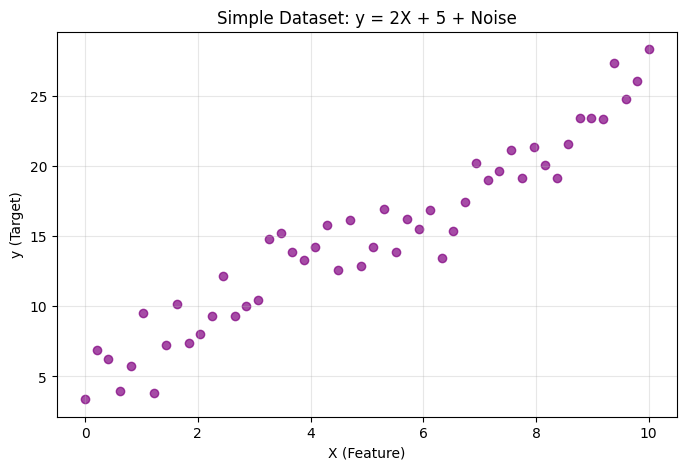

In [25]:
import numpy as np 
import matplotlib.pyplot as plt

# Fix randomness so results are the same every time (easy to reproduce)
np.random.seed(123)

# X: 50 points from 0 to 10 (simple feature)
X = np.linspace(0, 10, 50).reshape(-1, 1)  # Reshape to make it compatible with math operations

# True relationship: y = 2*X + 5 + little noise (so data isn't perfectly straight)
y = 2 * X + 5 + np.random.randn(50, 1) * 1.5  # Noise makes it look like real data

# Plot the data to see what we're working with
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='purple', alpha=0.7)
plt.xlabel("X (Feature)")
plt.ylabel("y (Target)")
plt.title("Simple Dataset: y = 2X + 5 + Noise")
plt.grid(alpha=0.3)
plt.show()
